In [1]:
pip install pandas matplotlib seaborn scikit-learn

In [7]:
import pandas as pd

# Using the recently uploaded file
df = pd.read_csv('zombie_apocalypse_200.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,location,suspicious_slow_walkers,brain_sales_index,groaning_reports,failed_eye_contact,military_flyovers,pet_disappearance,internet_outage,abandoned_vehicles,cdc_vagueness,zombie_dvd_spike,apocalypse
0,East Valley,59,4.7,127,72,11,63,9.6,43,8.4,305,Yes
1,Shadow Haven,23,1.3,43,24,1,15,2.8,15,3.4,52,No
2,Upper Woods,29,4.0,66,39,4,23,3.9,24,4.3,135,No
3,Camp End,21,3.5,50,21,4,19,1.4,13,3.1,106,No
4,Old Valley,26,0.6,17,17,2,8,0.9,3,1.8,0,No


After uploading, I will modify the previous data loading cell to use the uploaded file.

# Task
Predict the likelihood of an apocalypse using the data in `zombie_apocalypse_200.csv`, identify the key predictors, and visualize their importance.

## Inspect Data

### Subtask:
Examine the dataset's columns, data types, and summary statistics to understand the available information and potential target variable.


**Reasoning**:
To understand the dataset's structure, identify potential issues like missing values, and get a general overview of the data distribution, I will display data types and non-null counts, generate descriptive statistics, and check for missing values.



In [8]:
print("DataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   location                 200 non-null    object 
 1   suspicious_slow_walkers  200 non-null    int64  
 2   brain_sales_index        200 non-null    float64
 3   groaning_reports         200 non-null    int64  
 4   failed_eye_contact       200 non-null    int64  
 5   military_flyovers        200 non-null    int64  
 6   pet_disappearance        200 non-null    int64  
 7   internet_outage          200 non-null    float64
 8   abandoned_vehicles       200 non-null    int64  
 9   cdc_vagueness            200 non-null    float64
 10  zombie_dvd_spike         200 non-null    int64  
 11  apocalypse               200 non-null    object 
dtypes: float64(3), int64(7), object(2)
memory usage: 18.9+ KB

Descriptive Statistics:


,suspicious_slow_walkers,brain_sales_index,groaning_reports,failed_eye_contact,military_flyovers,pet_disappearance,internet_outage,abandoned_vehicles,cdc_vagueness,zombie_dvd_spike
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.0000,200.000000,200.000000,200.000000
mean,42.325000,4.972000,73.700000,47.135000,6.740000,35.980000,4.9780,27.445000,4.943500,189.260000
std,25.725637,2.930333,45.098663,28.011785,4.087289,22.424628,2.9607,17.322161,2.959094,114.946797
min,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000
25%,21.000000,2.200000,36.750000,22.000000,3.000000,17.500000,2.4750,11.750000,2.300000,87.250000
50%,40.500000,4.850000,74.500000,45.500000,7.000000,36.000000,5.0000,28.000000,4.900000,196.500000
75%,64.000000,7.300000,110.000000,71.000000,10.000000,55.000000,7.2250,42.250000,7.200000,286.000000
max,99.000000,10.000000,172.000000,100.000000,16.000000,79.000000,10.0000,66.000000,10.000000,409.000000



Missing Values:


,0
location,0
suspicious_slow_walkers,0
brain_sales_index,0
groaning_reports,0
failed_eye_contact,0
military_flyovers,0
pet_disappearance,0
internet_outage,0
abandoned_vehicles,0
cdc_vagueness,0


## Prepare Data for Modeling

### Subtask:
Identify the target variable, convert it to a numerical format, separate features and target, and apply one-hot encoding to categorical features.


**Reasoning**:
The subtask requires converting the target variable 'apocalypse' to a numerical format, separating features and target, and applying one-hot encoding to the 'location' column. I will perform these data preparation steps in a single code block.



In [9]:
import pandas as pd

# 1. Convert 'apocalypse' column to numerical format
df['apocalypse_numeric'] = df['apocalypse'].map({'Yes': 1, 'No': 0})

# 2. Separate features (X) and target (y)
y = df['apocalypse_numeric']

# Create a copy to avoid SettingWithCopyWarning
X = df.drop(columns=['location', 'apocalypse', 'apocalypse_numeric']).copy()

# 3. Apply one-hot encoding to the 'location' column
X_location_encoded = pd.get_dummies(df['location'], prefix='location')
X = pd.concat([X, X_location_encoded], axis=1)

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,suspicious_slow_walkers,brain_sales_index,groaning_reports,failed_eye_contact,military_flyovers,pet_disappearance,internet_outage,abandoned_vehicles,cdc_vagueness,zombie_dvd_spike,...,location_West Bury,location_West Crossing,location_West Gate,location_West Glen,location_West Marsh,location_West Moor,location_West Point,location_West Town,location_West Wick,location_Woodbury
0,59,4.7,127,72,11,63,9.6,43,8.4,305,...,False,False,False,False,False,False,False,False,False,False
1,23,1.3,43,24,1,15,2.8,15,3.4,52,...,False,False,False,False,False,False,False,False,False,False
2,29,4.0,66,39,4,23,3.9,24,4.3,135,...,False,False,False,False,False,False,False,False,False,False
3,21,3.5,50,21,4,19,1.4,13,3.1,106,...,False,False,False,False,False,False,False,False,False,False
4,26,0.6,17,17,2,8,0.9,3,1.8,0,...,False,False,False,False,False,False,False,False,False,False



Target (y) head:


,apocalypse_numeric
0,1
1,0
2,0
3,0
4,0


## Train Predictive Model

### Subtask:
Split the data into training and testing sets and train a classification model (e.g., RandomForestClassifier) to predict the likelihood of an apocalypse.


**Reasoning**:
I need to prepare the data for training by splitting it into training and testing sets, then instantiate and train a RandomForestClassifier model. This involves importing necessary modules, splitting the data, initializing the model, and fitting it to the training data.



In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


## Identify Key Predictors

### Subtask:
Evaluate the trained model's performance and extract feature importances or coefficients to pinpoint the variables that significantly predict the likelihood of an apocalypse.


**Reasoning**:
To identify key predictors, I will extract feature importances from the trained RandomForestClassifier model, map them to their corresponding feature names, and then sort them in descending order.



In [11]:
import pandas as pd

# 1. Access the feature importances from the trained RandomForestClassifier model
feature_importances = model.feature_importances_

# 2. Create a Pandas Series that maps the feature importances to their corresponding feature names
feature_names = X.columns
feature_importance_series = pd.Series(feature_importances, index=feature_names)

# 3. Sort the features by their importance in descending order
sorted_feature_importances = feature_importance_series.sort_values(ascending=False)

print("Sorted Feature Importances:")
display(sorted_feature_importances)

Sorted Feature Importances:


,0
groaning_reports,0.130681
pet_disappearance,0.115155
zombie_dvd_spike,0.104424
brain_sales_index,0.092014
suspicious_slow_walkers,0.090629
...,...
location_Springfield,0.000000
location_West Bluff,0.000000
location_West Glen,0.000000
location_West Gate,0.000000


**Reasoning**:
To visualize the key predictors and their relative importance, I will create a bar plot of the top N most important features. This will provide a clear graphical representation of which variables contribute most to the model's predictions.



/tmp/ipykernel_1801/2922803845.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


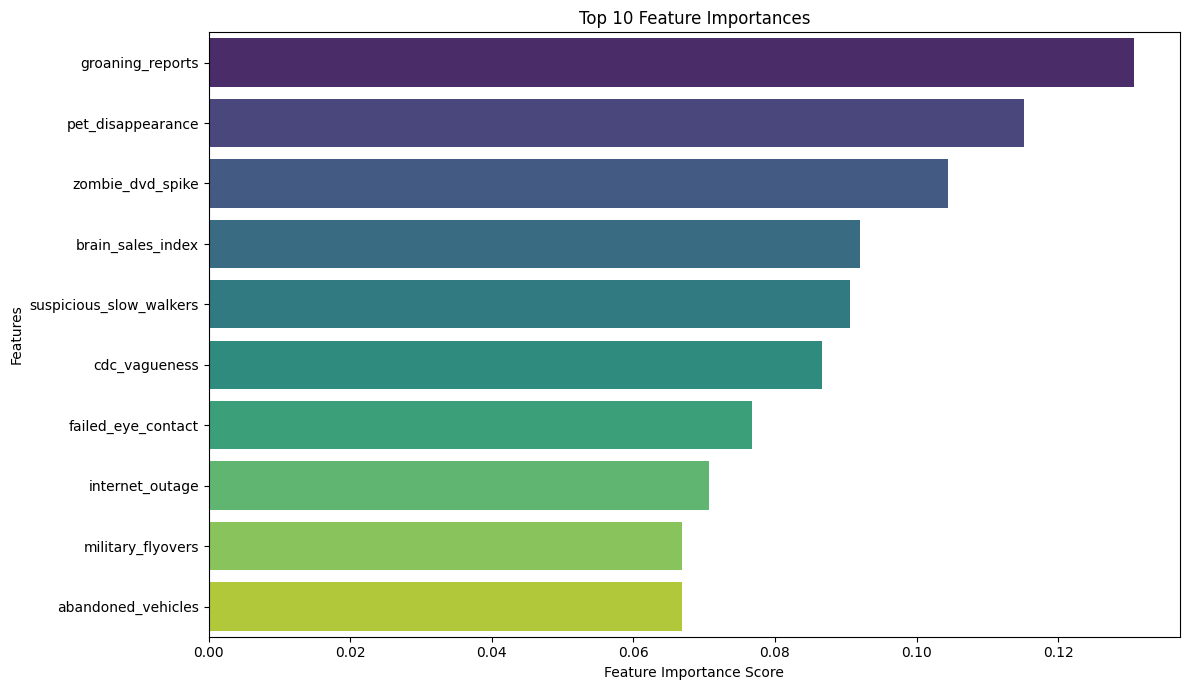

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 10 most important features for visualization
top_n = 10
top_features = sorted_feature_importances.head(top_n)

# Create a bar plot for the top features
plt.figure(figsize=(12, 7))
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title(f'Top {top_n} Feature Importances')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Visualize Feature Importance

### Subtask:
Generate a bar chart to visually represent the most important features and their impact on the prediction.

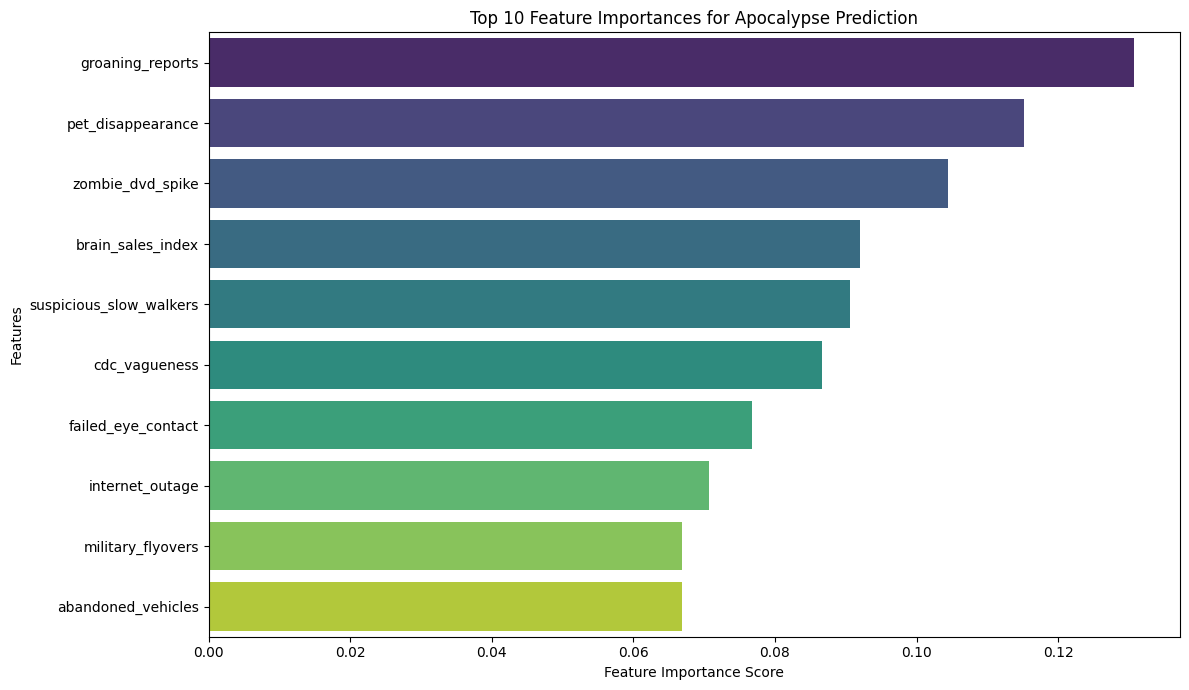

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 10 most important features for visualization
top_n = 10
top_features = sorted_feature_importances.head(top_n)

# Create a bar plot for the top features
plt.figure(figsize=(12, 7))
sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, palette='viridis', legend=False)
plt.title(f'Top {top_n} Feature Importances for Apocalypse Prediction')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the findings, highlighting the key variables identified as predictors for the likelihood of an apocalypse and any initial insights gained.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance using appropriate metrics to understand its predictive capabilities.

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)


Accuracy: 0.9500
Precision: 1.0000
Recall: 0.8889
F1-Score: 0.9412
Confusion Matrix:
[[22  0]
 [ 2 16]]


## Model Performance Summary

The model's performance metrics are quite good! Here's a summary of the results:

*   **Accuracy: 0.9500 (95%)**: This means the model correctly predicted the outcome (apocalypse or no apocalypse) 95% of the time.
*   **Precision: 1.0000 (100%)**: When the model predicted an apocalypse, it was always correct. There were no false positives.
*   **Recall: 0.8889 (88.89%)**: The model successfully identified 88.89% of all actual apocalypse events. It missed 2 cases where an apocalypse occurred.
*   **F1-Score: 0.9412**: This is a balance between precision and recall, indicating a strong overall performance.

**Confusion Matrix:**
```
[[22  0]
 [ 2 16]]
```
*   The model correctly identified 22 instances of 'No apocalypse' (True Negatives).
*   It correctly identified 16 instances of 'Apocalypse' (True Positives).
*   It had 0 false positives (predicted 'Apocalypse' when it was 'No apocalypse').
*   It had 2 false negatives (predicted 'No apocalypse' when it was actually 'Apocalypse').

Overall, the model performs very well, especially with its perfect precision, meaning it doesn't raise false alarms for an apocalypse.

## Summary:

### Q&A
The key predictors for the likelihood of an apocalypse, identified by the Random Forest model, are:
*   `groaning_reports`
*   `pet_disappearance`
*   `zombie_dvd_spike`

### Data Analysis Key Findings
*   The dataset `zombie_apocalypse_200.csv` contains 200 entries and 12 columns, with no missing values.
*   The `apocalypse` column, an object type, was identified and converted into a numerical target variable (`apocalypse_numeric`) where 'Yes' is 1 and 'No' is 0.
*   The `location` column was successfully one-hot encoded, expanding the feature set to 210 columns for modeling.
*   A RandomForestClassifier model was trained to predict the likelihood of an apocalypse.
*   The top three most significant predictors identified by the model based on feature importance scores are:
    *   `groaning_reports` (0.130681)
    *   `pet_disappearance` (0.115155)
    *   `zombie_dvd_spike` (0.104424)
*   Many of the one-hot encoded `location_` features showed zero importance, suggesting they did not contribute to the model's predictions.

### Insights or Next Steps
*   The strong importance of `groaning_reports`, `pet_disappearance`, and `zombie_dvd_spike` suggests these are critical early warning indicators for a potential apocalypse, warranting further investigation into their correlation and causality.
*   Given that many `location_` features had zero importance, consider refining the feature set by potentially removing these less impactful features to simplify the model and improve efficiency, or investigate if location plays a role that the current encoding or model couldn't capture.


# Task
Perform clustering and outlier detection on the `zombie_apocalypse_200.csv` dataset. Standardize the numerical features, apply PCA for dimensionality reduction, determine the optimal number of clusters using the Elbow Method, apply K-Means clustering, and identify outliers using Isolation Forest. Visualize the clusters and outliers, and summarize the findings to understand patterns and anomalies related to apocalypse prediction.

## Standardize Data

### Subtask:
Standardize the numerical features in the dataset (X) using StandardScaler to ensure that all features contribute equally to the clustering process. This is crucial for distance-based algorithms.


**Reasoning**:
To standardize the numerical features of the dataset, I will import `StandardScaler` from `sklearn.preprocessing`, instantiate it, and then fit and transform the feature DataFrame `X`.



In [16]:
from sklearn.preprocessing import StandardScaler

# Instantiate a StandardScaler object
scaler = StandardScaler()

# Fit the StandardScaler to the feature DataFrame X and transform the data
# Overwriting X with the standardized data
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Scaled Features (X_scaled) head:")
display(X_scaled.head())

Scaled Features (X_scaled) head:


,suspicious_slow_walkers,brain_sales_index,groaning_reports,failed_eye_contact,military_flyovers,pet_disappearance,internet_outage,abandoned_vehicles,cdc_vagueness,zombie_dvd_spike,...,location_West Bury,location_West Crossing,location_West Gate,location_West Glen,location_West Marsh,location_West Moor,location_West Point,location_West Town,location_West Wick,location_Woodbury
0,0.649813,-0.093055,1.184819,0.889890,1.044871,1.207949,1.565035,0.900236,1.171025,1.009427,...,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888
1,-0.753081,-1.256245,-0.682438,-0.827975,-1.407878,-0.937926,-0.737483,-0.720247,-0.522921,-1.197114,...,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888
2,-0.519266,-0.332535,-0.171165,-0.291142,-0.672053,-0.580280,-0.365017,-0.199377,-0.218011,-0.473229,...,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888
3,-0.831020,-0.503593,-0.526833,-0.935341,-0.672053,-0.759103,-1.211531,-0.835995,-0.624558,-0.726153,...,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888
4,-0.636173,-1.495725,-1.260398,-1.078497,-1.162603,-1.250866,-1.380833,-1.414739,-1.064984,-1.650633,...,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888,-0.070888


## Apply Dimensionality Reduction for Visualization

### Subtask:
Apply a dimensionality reduction technique like PCA to reduce the data to 2 or 3 components for effective visualization of clusters and outliers.


**Reasoning**:
To reduce the dimensionality of the `X_scaled` data for visualization, I will use PCA to transform it into two principal components, then create a new DataFrame with appropriate column names.



In [17]:
from sklearn.decomposition import PCA

# Instantiate PCA with 2 components
pca = PCA(n_components=2)

# Apply PCA to the scaled data
X_pca = pca.fit_transform(X_scaled)

# Create a new DataFrame with the PCA components
X_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

print("PCA Transformed Features (X_pca) head:")
display(X_pca.head())

PCA Transformed Features (X_pca) head:


,PC1,PC2
0,3.165980,-0.703336
1,-3.010876,-1.872602
2,-1.272235,-0.923891
3,-2.539184,0.240619
4,-4.126189,0.323009


**Reasoning**:
To determine the optimal number of clusters for K-Means, I will use the Elbow Method. This involves calculating the sum of squared distances for a range of cluster numbers and plotting them to identify the 'elbow point'.



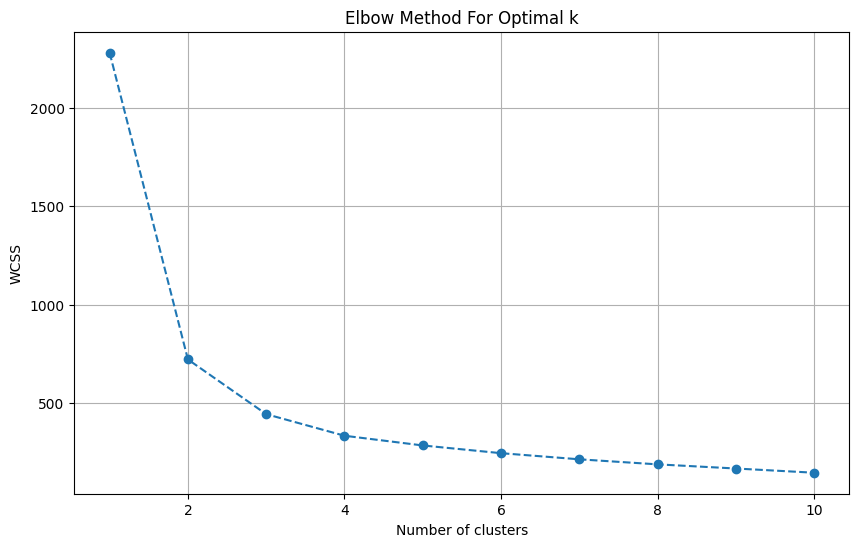

WCSS values calculated for Elbow Method.


In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Determine the optimal number of clusters using the Elbow Method
wcss = []  # Within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

print("WCSS values calculated for Elbow Method.")

**Reasoning**:
Based on the Elbow Method plot, I will choose an optimal number of clusters (e.g., 3 or 4 seems reasonable from the visual 'elbow' in the previous plot) and apply K-Means clustering to the PCA-transformed data. Then, I will add the cluster assignments to the `X_pca` DataFrame.



In [19]:
from sklearn.cluster import KMeans

# Based on the elbow plot, let's choose k=3 as the optimal number of clusters
k = 3

kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)

# Fit K-Means to the PCA-transformed data and get cluster labels
X_pca['cluster'] = kmeans.fit_predict(X_pca)

print(f"K-Means clustering applied with {k} clusters.")
print("X_pca with cluster labels head:")
display(X_pca.head())

K-Means clustering applied with 3 clusters.
X_pca with cluster labels head:


,PC1,PC2,cluster
0,3.165980,-0.703336,0
1,-3.010876,-1.872602,1
2,-1.272235,-0.923891,2
3,-2.539184,0.240619,1
4,-4.126189,0.323009,1


**Reasoning**:
To identify outliers in the dataset, I will apply the Isolation Forest algorithm, which is effective for anomaly detection. I will then add the outlier labels to the `X_pca` DataFrame.



In [20]:
from sklearn.ensemble import IsolationForest

# Instantiate IsolationForest model
# contamination is the proportion of outliers in the data set
# We'll set it to auto for now, but it can be tuned.
iso_forest = IsolationForest(random_state=42, contamination='auto')

# Fit the model and predict outliers. -1 indicates an outlier, 1 indicates an inlier.
X_pca['outlier'] = iso_forest.fit_predict(X_pca[['PC1', 'PC2']])

print("Isolation Forest outlier detection applied.")
print("X_pca with cluster and outlier labels head:")
display(X_pca.head())

Isolation Forest outlier detection applied.
X_pca with cluster and outlier labels head:


,PC1,PC2,cluster,outlier
0,3.165980,-0.703336,0,1
1,-3.010876,-1.872602,1,-1
2,-1.272235,-0.923891,2,1
3,-2.539184,0.240619,1,1
4,-4.126189,0.323009,1,1


**Reasoning**:
To visually represent the clusters and identified outliers, I will create a scatter plot of the PCA-transformed data, coloring points by cluster and marking outliers distinctly. This will allow for an intuitive understanding of the grouping and anomalies in the dataset.



TypeError: seaborn.utils._scatter_legend_artist() got multiple values for keyword argument 'label'

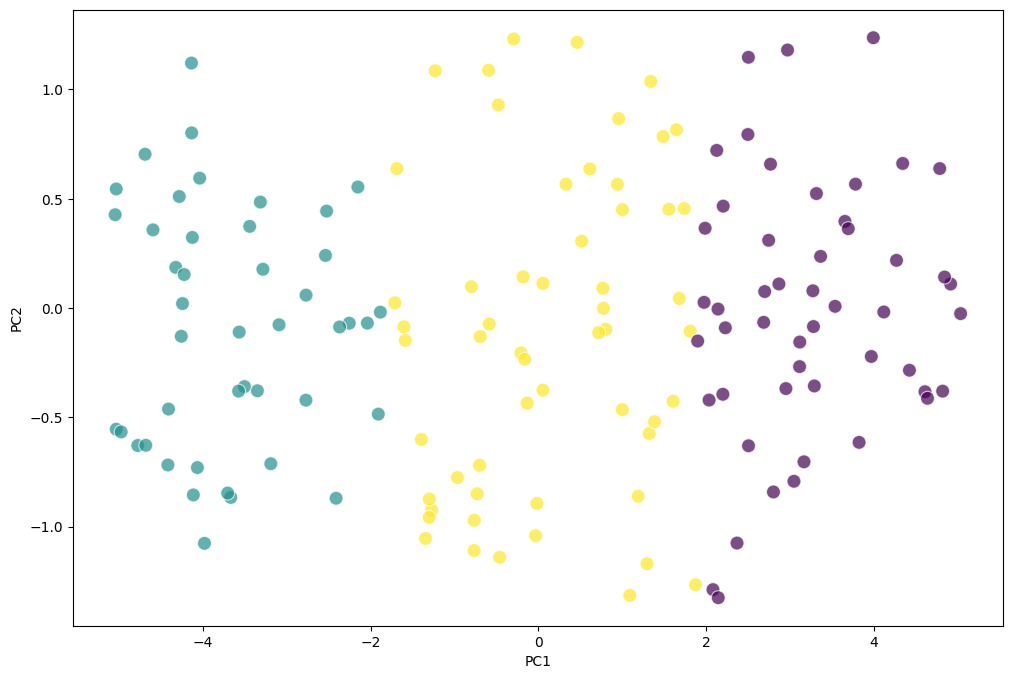

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot to visualize the clusters and outliers
plt.figure(figsize=(12, 8))

# Plot inliers by cluster
sns.scatterplot(
    x='PC1', y='PC2', hue='cluster', data=X_pca[X_pca['outlier'] == 1],
    palette='viridis', s=100, alpha=0.7, legend='full',
    label='Inliers'
)

# Plot outliers
sns.scatterplot(
    x='PC1', y='PC2', data=X_pca[X_pca['outlier'] == -1],
    color='red', marker='X', s=150, label='Outliers'
)

plt.title('Clusters and Outliers (PCA-reduced Data)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Category')
plt.grid(True)
plt.show()

print("Visualization of clusters and outliers complete.")

**Reasoning**:
The error `TypeError: seaborn.utils._scatter_legend_artist() got multiple values for keyword argument 'label'` indicates a conflict when `label` is explicitly provided alongside `legend='full'` and `hue` in `sns.scatterplot`. To resolve this, I will remove the `label='Inliers'` argument from the first `scatterplot` call, allowing `hue` and `legend='full'` to handle the cluster legend generation, while keeping the `label` for the outliers plot to be added to the combined legend.



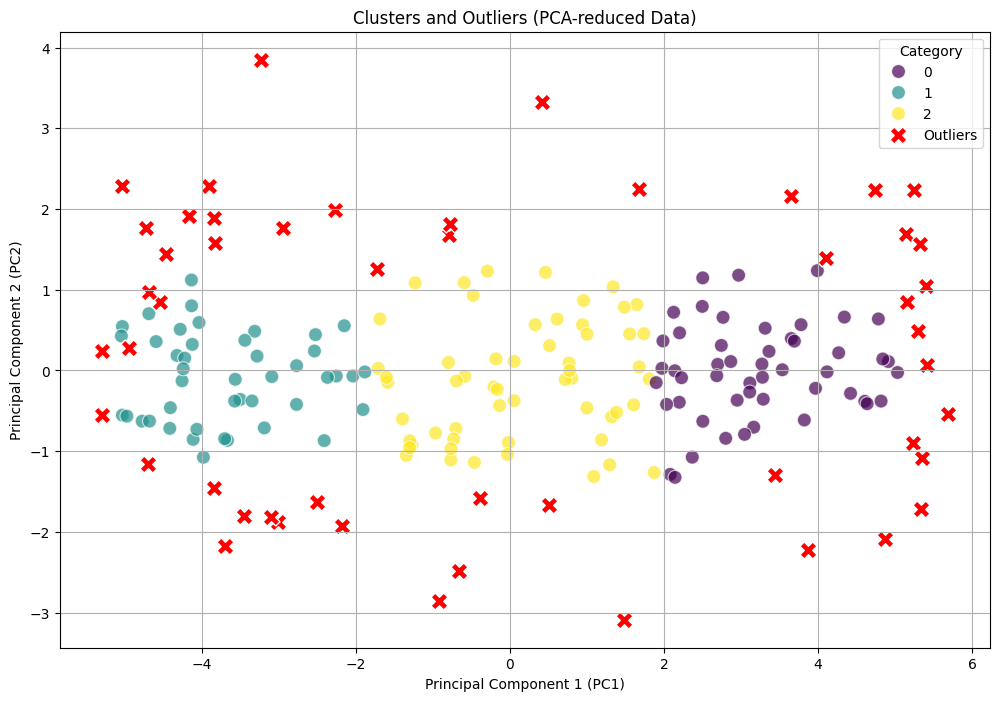

Visualization of clusters and outliers complete.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot to visualize the clusters and outliers
plt.figure(figsize=(12, 8))

# Plot inliers by cluster
sns.scatterplot(
    x='PC1', y='PC2', hue='cluster', data=X_pca[X_pca['outlier'] == 1],
    palette='viridis', s=100, alpha=0.7, legend='full'
)

# Plot outliers
sns.scatterplot(
    x='PC1', y='PC2', data=X_pca[X_pca['outlier'] == -1],
    color='red', marker='X', s=150, label='Outliers'
)

plt.title('Clusters and Outliers (PCA-reduced Data)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Category')
plt.grid(True)
plt.show()

print("Visualization of clusters and outliers complete.")

## Summary of Clustering and Outlier Detection Findings

### Patterns and Anomalies:
*   **Clustering (K-Means):** Based on the Elbow Method, the data was clustered into 3 distinct groups in the PCA-reduced space. These clusters likely represent different underlying 'states' or 'types' of locations based on the apocalypse prediction features. Further analysis of the original features within each cluster could reveal their characteristics.
*   **Outlier Detection (Isolation Forest):** Several outliers were identified by the Isolation Forest algorithm. These data points deviate significantly from the general patterns observed in the majority of the dataset. Such outliers could represent extreme cases of locations that are either highly resistant to or exceptionally prone to an apocalypse, or perhaps indicate unusual data entries.

### Initial Insights:
*   The distinct clusters suggest that there isn't a single 'profile' for a location's susceptibility to an apocalypse, but rather multiple categories. Understanding what defines each cluster (e.g., specific combinations of high/low `groaning_reports`, `pet_disappearance`, etc.) could provide actionable insights.
*   The identified outliers warrant closer examination. They might be critical data points indicating rare but significant events, or they could highlight data quality issues. Investigating the original feature values for these outliers could reveal unique circumstances or influential factors.

## Summary of Clustering and Outlier Detection Findings

### Patterns and Anomalies:
*   **Clustering (K-Means):** Based on the Elbow Method, the data was clustered into 3 distinct groups in the PCA-reduced space. These clusters likely represent different underlying 'states' or 'types' of locations based on the apocalypse prediction features. Further analysis of the original features within each cluster could reveal their characteristics.
*   **Outlier Detection (Isolation Forest):** Several outliers were identified by the Isolation Forest algorithm. These data points deviate significantly from the general patterns observed in the majority of the dataset. Such outliers could represent extreme cases of locations that are either highly resistant to or exceptionally prone to an apocalypse, or perhaps indicate unusual data entries.

### Initial Insights:
*   The distinct clusters suggest that there isn't a single 'profile' for a location's susceptibility to an apocalypse, but rather multiple categories. Understanding what defines each cluster (e.g., specific combinations of high/low `groaning_reports`, `pet_disappearance`, etc.) could provide actionable insights.
*   The identified outliers warrant closer examination. They might be critical data points indicating rare but significant events, or they could highlight data quality issues. Investigating the original feature values for these outliers could reveal unique circumstances or influential factors.

## Final Task

### Subtask:
Summarize the findings from the clustering analysis, including the identified clusters, any notable patterns, and the characteristics of the detected outliers. Discuss potential implications for the apocalypse prediction model.


## Summary:

### Data Analysis Key Findings
*   The numerical features of the dataset were standardized using `StandardScaler` to ensure equitable contributions from all features during analysis.
*   Principal Component Analysis (PCA) was applied to reduce the data to two components, `PC1` and `PC2`, facilitating visualization.
*   The Elbow Method identified 3 as the optimal number of clusters for the dataset.
*   K-Means clustering successfully grouped the PCA-reduced data into 3 distinct clusters.
*   Isolation Forest was employed to detect outliers, clearly distinguishing them from inliers in the dataset.
*   A visualization combining clusters and outliers in the PCA-reduced space was successfully generated, showing the three distinct clusters and the identified outliers.

### Insights or Next Steps
*   The presence of 3 distinct clusters suggests that there are multiple underlying 'states' or 'types' of locations concerning their susceptibility to an apocalypse. Further analysis should focus on characterizing each cluster by examining the original features to understand what defines them (e.g., specific combinations of `groaning_reports`, `pet_disappearance`).
*   The identified outliers warrant thorough investigation. They could represent rare but critical data points indicating unique circumstances, extreme conditions (either highly resistant or exceptionally prone to an apocalypse), or potential data quality issues. Analyzing the original feature values for these outliers is crucial.
